# Dual-Output Regression (kmin + kmax) - PyTorch

Tests whether predicting both parameters together improves accuracy.

**Memory optimized**: Lazy HDF5 loading.

In [1]:
from pathlib import Path
import json
import time

import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
DATA_FILE = Path('../../data/raw/randomboth_balancedkmax_kmin1-16_kmax2-64_128x128_32000.h5')
OUTPUT_DIR = Path('../../outputs/comparison/dual_output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EPOCHS = 100
EARLY_STOP_PATIENCE = 15

KMIN_RANGE = (1, 16)
KMAX_RANGE = (2, 64)

if not DATA_FILE.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_FILE}')
print(f'Dataset: {DATA_FILE}')

Dataset: ../../data/raw/randomboth_balancedkmax_kmin1-16_kmax2-64_128x128_32000.h5


## Lazy-Loading Dataset

In [3]:
class HDF5DualDataset(Dataset):
    def __init__(self, h5_path, indices, kmin_values, kmax_values, kmin_range, kmax_range):
        self.h5_path = h5_path
        self.indices = indices
        self.kmin = kmin_values[indices]
        self.kmax = kmax_values[indices]
        self.kmin_range = kmin_range
        self.kmax_range = kmax_range
        self._h5_file = None
    
    def _get_h5(self):
        if self._h5_file is None:
            self._h5_file = h5py.File(self.h5_path, 'r')
        return self._h5_file
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        h5 = self._get_h5()
        img = h5['images'][self.indices[idx]].astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = img[np.newaxis, :, :]
        
        y_kmin = (self.kmin[idx] - self.kmin_range[0]) / (self.kmin_range[1] - self.kmin_range[0])
        y_kmax = (self.kmax[idx] - self.kmax_range[0]) / (self.kmax_range[1] - self.kmax_range[0])
        
        return torch.from_numpy(img), torch.tensor([y_kmin, y_kmax], dtype=torch.float32)
    
    def __del__(self):
        if self._h5_file is not None:
            self._h5_file.close()

In [4]:
with h5py.File(DATA_FILE, 'r') as f:
    n_samples = f['images'].shape[0]
    kmin_values = f['parameters/k_min'][:]
    kmax_values = f['parameters/k_max'][:]

print(f'Samples: {n_samples}')
print(f'kmin: [{kmin_values.min():.1f}, {kmin_values.max():.1f}]')
print(f'kmax: [{kmax_values.min():.1f}, {kmax_values.max():.1f}]')

Samples: 32000
kmin: [1.0, 16.0]
kmax: [4.0, 64.0]


In [5]:
indices = np.arange(n_samples)
train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

train_ds = HDF5DualDataset(DATA_FILE, train_idx, kmin_values, kmax_values, KMIN_RANGE, KMAX_RANGE)
val_ds = HDF5DualDataset(DATA_FILE, val_idx, kmin_values, kmax_values, KMIN_RANGE, KMAX_RANGE)
test_ds = HDF5DualDataset(DATA_FILE, test_idx, kmin_values, kmax_values, KMIN_RANGE, KMAX_RANGE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')

Train: 25600, Val: 3200, Test: 3200


## Dual-Output Model

In [6]:
class DualOutputResNet(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.backbone = models.resnet50(weights=None)
        self.backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        
        self.shared = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        self.kmin_head = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 1)
        )
        self.kmax_head = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 1)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        shared = self.shared(features)
        kmin = self.kmin_head(shared)
        kmax = self.kmax_head(shared)
        return torch.cat([kmin, kmax], dim=1)

model = DualOutputResNet(in_channels=1).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 24,059,330


In [7]:
criterion = nn.HuberLoss(delta=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

In [8]:
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience = 0

start = time.time()
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'):
                out = model(xb)
                loss = criterion(out, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_loader.dataset)
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model(xb), yb).item() * len(xb)
    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience = 0
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pt')
    else:
        patience += 1
        if patience >= EARLY_STOP_PATIENCE:
            print(f'Early stopping')
            break

train_time = time.time() - start
print(f'\nTraining: {train_time/60:.1f} min')

Epoch   1 | Train: 0.0119 | Val: 0.0092
Epoch   2 | Train: 0.0091 | Val: 0.0094
Epoch   3 | Train: 0.0080 | Val: 0.0074
Epoch   4 | Train: 0.0076 | Val: 0.0110
Epoch   5 | Train: 0.0072 | Val: 0.0100
Epoch   6 | Train: 0.0068 | Val: 0.0077
Epoch   7 | Train: 0.0065 | Val: 0.0103
Epoch   8 | Train: 0.0063 | Val: 0.0094
Epoch   9 | Train: 0.0060 | Val: 0.0090
Epoch  10 | Train: 0.0051 | Val: 0.0080
Epoch  11 | Train: 0.0046 | Val: 0.0087
Epoch  12 | Train: 0.0044 | Val: 0.0077
Epoch  13 | Train: 0.0041 | Val: 0.0086
Epoch  14 | Train: 0.0039 | Val: 0.0084
Epoch  15 | Train: 0.0038 | Val: 0.0087
Epoch  16 | Train: 0.0033 | Val: 0.0084
Epoch  17 | Train: 0.0031 | Val: 0.0067
Epoch  18 | Train: 0.0030 | Val: 0.0081
Epoch  19 | Train: 0.0028 | Val: 0.0075
Epoch  20 | Train: 0.0028 | Val: 0.0084
Epoch  21 | Train: 0.0027 | Val: 0.0076
Epoch  22 | Train: 0.0026 | Val: 0.0080
Epoch  23 | Train: 0.0025 | Val: 0.0072
Epoch  24 | Train: 0.0024 | Val: 0.0076
Epoch  25 | Train: 0.0023 | Val: 0.0074


## Evaluate

In [9]:
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_model.pt'))
model.eval()

preds, targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds.append(model(xb.to(DEVICE)).cpu())
        targets.append(yb)

y_pred = torch.cat(preds).numpy()
y_true = torch.cat(targets).numpy()

# Denormalize
kmin_pred = y_pred[:, 0] * (KMIN_RANGE[1] - KMIN_RANGE[0]) + KMIN_RANGE[0]
kmax_pred = y_pred[:, 1] * (KMAX_RANGE[1] - KMAX_RANGE[0]) + KMAX_RANGE[0]
kmin_true = y_true[:, 0] * (KMIN_RANGE[1] - KMIN_RANGE[0]) + KMIN_RANGE[0]
kmax_true = y_true[:, 1] * (KMAX_RANGE[1] - KMAX_RANGE[0]) + KMAX_RANGE[0]

results = {}
for name, pred, true in [('kmin', kmin_pred, kmin_true), ('kmax', kmax_pred, kmax_true)]:
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    results[name] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    print(f'{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.4f}')

kmin: MAE=1.118, RMSE=1.395, R²=0.8973
kmax: MAE=8.252, RMSE=11.059, R²=0.6083


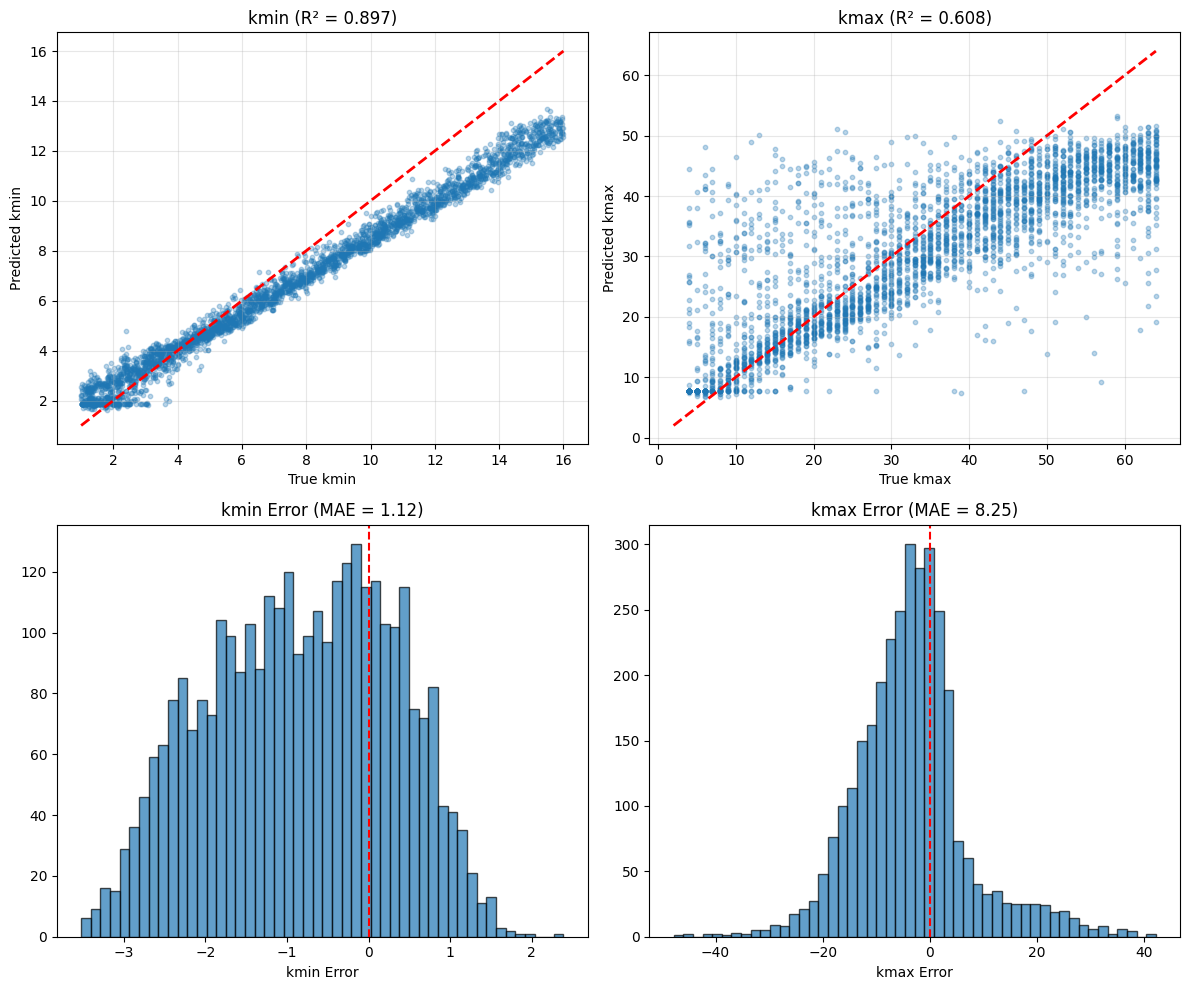

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(kmin_true, kmin_pred, alpha=0.3, s=10)
axes[0, 0].plot([KMIN_RANGE[0], KMIN_RANGE[1]], [KMIN_RANGE[0], KMIN_RANGE[1]], 'r--', lw=2)
axes[0, 0].set_xlabel('True kmin')
axes[0, 0].set_ylabel('Predicted kmin')
axes[0, 0].set_title(f'kmin (R² = {results["kmin"]["r2"]:.3f})')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(kmax_true, kmax_pred, alpha=0.3, s=10)
axes[0, 1].plot([KMAX_RANGE[0], KMAX_RANGE[1]], [KMAX_RANGE[0], KMAX_RANGE[1]], 'r--', lw=2)
axes[0, 1].set_xlabel('True kmax')
axes[0, 1].set_ylabel('Predicted kmax')
axes[0, 1].set_title(f'kmax (R² = {results["kmax"]["r2"]:.3f})')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(kmin_pred - kmin_true, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='r', linestyle='--')
axes[1, 0].set_xlabel('kmin Error')
axes[1, 0].set_title(f'kmin Error (MAE = {results["kmin"]["mae"]:.2f})')

axes[1, 1].hist(kmax_pred - kmax_true, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(0, color='r', linestyle='--')
axes[1, 1].set_xlabel('kmax Error')
axes[1, 1].set_title(f'kmax Error (MAE = {results["kmax"]["mae"]:.2f})')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dual_output_results.png', dpi=150)
plt.show()

In [11]:
output = {
    'model': 'dual_output_resnet50',
    'dataset': str(DATA_FILE.name),
    'kmin': {k: float(v) for k, v in results['kmin'].items()},
    'kmax': {k: float(v) for k, v in results['kmax'].items()},
    'training_time_min': train_time / 60,
    'epochs': len(history['train_loss'])
}
with open(OUTPUT_DIR / 'results.json', 'w') as f:
    json.dump(output, f, indent=2)
print(f'Saved to {OUTPUT_DIR}')

Saved to ../../outputs/comparison/dual_output
